# TO DO:
- fare tutti i markdown in bella
- aggiungere "bibliografia" in fondo con link documentation: alla fine e link "[ ]" oppure link direttamente nel markdown? (a lucry piace di più la bibliografia alla fine e i link [] tipo paper :) )
- magari salviamo l'immagine finale con tutta la roba per tutte le immagini così lo riesce a vedere al volo che viene per tutte senza dover modificare il nome e runnare dodici volte il codice


[comandi per formattare i markdown](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# esame data
# progetto
# nomi 

# breve descrizione progetto
setup generale

task da svolgere (scrivi numerazione usata qua quindi task 1.1,1.2,1.3 task 2)

In [271]:
# import tutto 
import numpy as np
import cv2
from matplotlib import pyplot as plt
import math

liner_flag = False
defect_flag = False
final_results= ""

Setup 

In [272]:
img_name = "d_18"
show_steps = True


loadiamo immagine in color per poi farla visualizzare con i cerchi colorati però poi ci serve in gray scale per fare tutta la roba quindi ci creiamo anche la versione grayscale

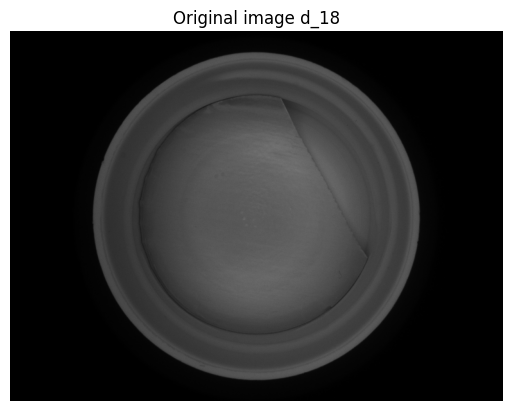

In [273]:
img_color = cv2.imread("cap-inspection-images/project_1_liner_inspection/"+img_name+".bmp")
img = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)
if show_steps :
    plt.figure()
    plt.title("Original image "+img_name)
    plt.imshow(img,cmap='gray',vmin=0,vmax=255)
    plt.axis('off')
    plt.show()

###  spiegazione tool usati: 
- gaussian filtering (cos'è, parametri, come scegliamo i parametri in questo caso, perchè questo piuttosto che altri)
- CLAHE - cos'è e perchè lo vogliamo usare, parametri 
- circlesHough (cos'è, come funziona a grandi linee, perchè lo usiamo, parametri)
- canny 
- HoughLines (cos'è, come funziona a grandi linee, perchè lo usiamo, parametri)


2 opzioni: li mettiamo tutti qua inordine di uso e scrivendo dove vengono usati dopo tipo reference OPPURE li mettiamo di volta in volta quando li usiamo nei vari step

caso uno magari qua facciamo una spiegazione generale e poi step per step l'uso specifico e soprattutto la scelta dei parametri


## ENHANCING THE IMAGE 

CLAHE + GAUSSIAN

spiegare perchè gaussian

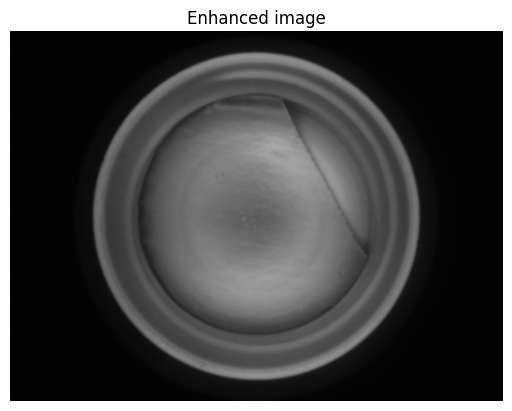

In [274]:

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(5,5))
img_cl = clahe.apply(img)
img_blur = cv2.GaussianBlur(img_cl,(7,7),1.5)

if show_steps :
    plt.figure()
    plt.title("Enhanced image")
    plt.imshow(img_blur,cmap="gray",vmin=0,vmax=255)
    plt.axis('off')
    plt.show()

## TASK 1
### trovare il cerchio esterno
usiamo houghcircles mettendo parametri 40,100,80 perche pochi centri, canny con threshold alta mi prende solo il bordo esterno con grandiente alto, vogliamo cerchi belli

CAP OUTLINE 
Center: x =  382.5  y =  287.5  
Diameter =  509.2


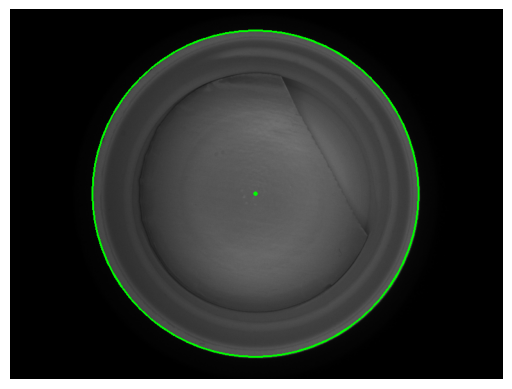

In [ ]:
circles_out = cv2.HoughCircles(img_blur,cv2.HOUGH_GRADIENT, 1, 40,param1=100,param2=80) 
center_out = (circles_out[0][0][0],circles_out[0][0][1])
radius_out = circles_out[0][0][2]

img_color_out=img_color.copy()
cv2.circle(img_color_out,(int(center_out[0]),int(center_out[1])),int(radius_out),color=(0, 255, 0),thickness=2)
cv2.circle(img_color_out,(int(center_out[0]),int(center_out[1])),int(2),color=(0, 255, 0),thickness=2)

print("CAP OUTLINE \n Center: x = ", center_out[0]," y = ",center_out[1]," \n Diameter = ",radius_out*2 )
plt.imshow(img_color_out)
plt.axis('off')
plt.show()


img_color_final=img_color.copy() # to use for all steps
cv2.circle(img_color_final,(int(center_out[0]),int(center_out[1])),int(radius_out),color=(0, 255, 0),thickness=2)
cv2.circle(img_color_final,(int(center_out[0]),int(center_out[1])),int(2),color=(0, 255, 0),thickness=2)
final_results=final_results+"CAP OUTLINE -- Center: x = "+str(center_out[0])+" y = "+str(center_out[1])+" - Diameter = "+str(radius_out*2) + " \n"


## Liner inspection
 
### facciamo la roi 
- perche (perche ci interessa solo l'interno del cap e a fare così riusciamo a vedere solo le info utili con canny e compagnia bella)

dimensione della roi scelto empiricamente tra inscritto (veniva tagliato il liner) e circoscritto (rimaneva troppo il bordo esterno) in questo modo tagli il giusto

### troviamo se il liner c'è o no
nostra soluzione: usiamo houghcircles con un param aggiustati per avere il canny interno che mostra più cose 

funziona a trovare se c'è il liner perche nel caso no liner canny con questi parametri non mostra niente dentro il cap

metodo alternativo: seguendo hint della consegna si può fare con avg lightness ** o mettiamo qua le due righine o appendice **
```
avg=cv2.mean(img_roi)[0]
print(avg)              ########## LINER: intorno a 97 - NO LINER: intorno a 107 - "threshold"=102 
if avg>102 : 
    print("NO LINER")
else : 
    # cerca i difetti
```

### se il liner c'è trova se c'è difetti 
facciamo manualmente canny (che inspecta il magnitude of the gradient) e poi houghlines (perche lui in automatico non lo fa a differenza di houghcircles)

se trova linee vuol dire che c'è il difetto altrimenti no difetto
prendiamo la prima linea dato ceh tanto le tira fuori in ordine decrescente del valore dell'accomulatore (cioe ordine di "perfezione")

[LINK UTILE PER SPIEGAZIONE HOUGHLINES](https://learnopencv.com/hough-transform-with-opencv-c-python/)

LINER FOUND


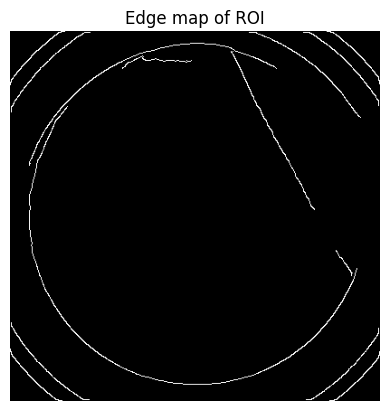

LINER DEFECT FOUND


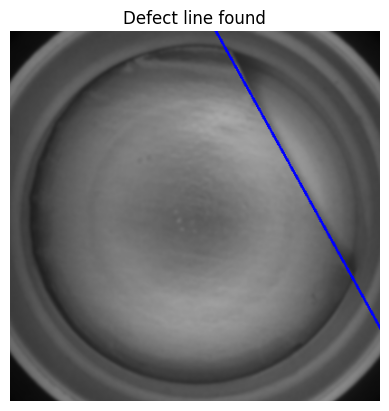

In [276]:
offset = radius_out*0.8 
x_max_roi=math.ceil(center_out[0]+offset)
x_min_roi=math.floor(center_out[0]-offset)
y_max_roi=math.ceil(center_out[1]+offset)
y_min_roi=math.floor(center_out[1]-offset)  
img_roi=img_blur[y_min_roi:y_max_roi,x_min_roi:x_max_roi]
img_roi_show=cv2.cvtColor(img_roi, cv2.COLOR_GRAY2RGB) 


circles_in = cv2.HoughCircles(img_roi,cv2.HOUGH_GRADIENT, 1, 50,param1=90,param2=80) 

line_layer=np.zeros_like(img_color) # useful for the optional requirement

if circles_in is not None and len(circles_in) > 0: 
    
    print("LINER FOUND")
    liner_flag= True

    edges = cv2.Canny(img_roi,40,80,apertureSize = 3)
    if show_steps :
        plt.figure()
        plt.title("Edge map of ROI")
        plt.imshow(edges,cmap='gray',vmin=0,vmax=255)
        plt.axis('off')
        plt.show() 
    

    lines = cv2.HoughLines(edges,1,np.pi/180,70)
    if lines is not None and len(lines) > 0:    
        
        print("LINER DEFECT FOUND")
        defect_flag= True

        rho, theta = lines[0][0] 
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv2.line(line_layer, (x1+x_min_roi, y1+y_min_roi), (x2+x_min_roi, y2+y_min_roi), (0, 0, 255), 2) # useful for the optional requirement
        
        if show_steps :
            cv2.line(img_roi_show, (x1, y1), (x2, y2), (0, 0, 255), 2)
            plt.figure()
            plt.title("Defect line found")
            plt.imshow(img_roi_show)
            plt.axis('off')
            plt.show()
        
    else: 
        print("NO LINER DEFECTS FOUND") 
        final_results=final_results+"NO LINER DEFECTS FOUND \n"

else : 
    print("NO LINER FOUND") 
    final_results=final_results+"NO LINER FOUND \n"


## task 2
liner segmentation
mostra liner e stampa info liner

risultato di houghcircles trovato prima 

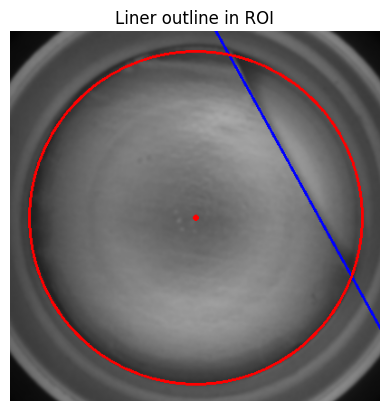

LINER OUTLINE
 Center: x =  383.5  y =  289.5 
 Diameter =  368.0


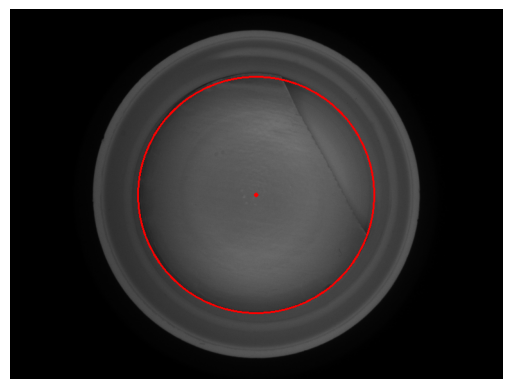

In [277]:
circle_liner_layer=np.zeros_like(img_color) # useful for the optional requirement

if liner_flag: 

    center_in = (circles_in[0][0][0],circles_in[0][0][1])
    radius_in = circles_in[0][0][2]
    
    cv2.circle(circle_liner_layer,(int(center_in[0])+x_min_roi,int(center_in[1])+y_min_roi),int(radius_in),color=(255,0, 0),thickness=2) # useful for the optional requirement

    if show_steps: 
        cv2.circle(img_roi_show,(int(center_in[0]),int(center_in[1])),int(radius_in),color=(255, 0, 0),thickness=2)
        cv2.circle(img_roi_show,(int(center_in[0]),int(center_in[1])),int(2),color=(255,0, 0),thickness=2)
        plt.figure()
        plt.title("Liner outline in ROI")
        plt.imshow(img_roi_show)
        plt.axis('off')
        plt.show()

    img_color_in=img_color.copy()
    cv2.circle(img_color_in,(int(center_in[0]+x_min_roi),int(center_in[1]+y_min_roi)),int(radius_in),color=(255, 0, 0),thickness=2)
    cv2.circle(img_color_in,(int(center_in[0]+x_min_roi),int(center_in[1]+y_min_roi)),int(2),color=(255, 0, 0),thickness=2)

    print("LINER OUTLINE\n Center: x = ", center_in[0]+x_min_roi," y = ",center_in[1]+y_min_roi,"\n Diameter = ",radius_in*2)
    plt.figure()
    plt.imshow(img_color_in)
    plt.axis('off')
    plt.show()


    cv2.circle(img_color_final,(int(center_in[0]+x_min_roi),int(center_in[1]+y_min_roi)),int(radius_in),color=(255, 0, 0),thickness=2)
    cv2.circle(img_color_final,(int(center_in[0]+x_min_roi),int(center_in[1]+y_min_roi)),int(2),color=(255, 0, 0),thickness=2)
    final_results=final_results+"LINER OUTLINE -- Center: x = "+str(center_in[0]+x_min_roi)+" y = "+str(center_in[1]+y_min_roi)+" - Diameter = "+str(radius_in*2) + " \n"



### optional requirement

print results and image with the rectangle around defect if present


lists with some points of which to make sure i only get two that are in the two different intersections i take the first and last <br>
Calculate line length <br>
Calculate perpendicular unit normal vector <br>
Define how wide you want the rectangle to be on each side of the line <br>
Calculate the four corners dynamically<br>
Format the points into an array for OpenCV<br>


ho trovato una domanda di stack overflow che da esattamente questo metodo (in caso ci sospettasse AI) [LINK](https://stackoverflow.com/questions/7854043/drawing-rectangle-between-two-points-with-arbitrary-width) - letteralmente primo risultato cercando "draw rectangle around segment line" su google 

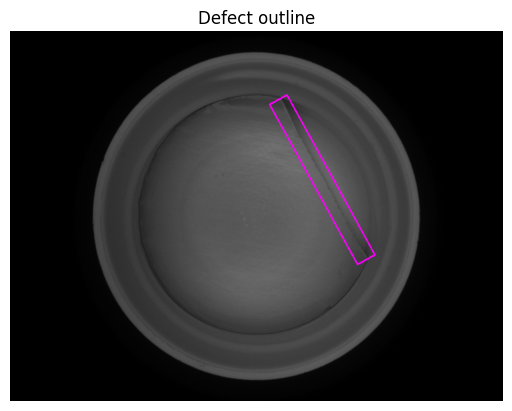

In [ ]:
if defect_flag:
    liner_layer=line_layer+circle_liner_layer
    mask = np.all(liner_layer == np.array([255, 0, 255], dtype=np.uint8), axis=2)
    y, x = np.where(mask) 

    x1=x[0]
    y1=y[0]
    x2=x[-1]
    y2=y[-1]

    dx = x2-x1
    dy = y2-y1
    length = math.sqrt(dx**2+dy**2)

    if length>0:
        nx = -dy/length
        ny = dx/length
        
        width = 15
        pt1 = [x1+width*nx, y1+width*ny]
        pt2 = [x1-width*nx, y1-width*ny]
        pt3 = [x2-width*nx, y2-width*ny]
        pt4 = [x2+width*nx, y2+width*ny]
        
        pts = np.array([pt1, pt2, pt3, pt4], dtype=np.int32)
        
        img_color_rect=img_color.copy()
        cv2.polylines(img_color_rect, [pts], isClosed=True, color=(255, 0, 255), thickness=2)
    
        plt.figure()
        plt.title("Defect outline")
        plt.imshow(img_color_rect)
        plt.axis('off')
        plt.show()



        cv2.polylines(img_color_final, [pts], isClosed=True, color=(255, 0, 255), thickness=2)
        final_results=final_results+"DEFECT DETECTED \n"


## Final results 

CAP OUTLINE -- Center: x = 382.5 y = 287.5 - Diameter = 509.2 
LINER OUTLINE -- Center: x = 383.5 y = 289.5 - Diameter = 368.0 
DEFECT DETECTED 



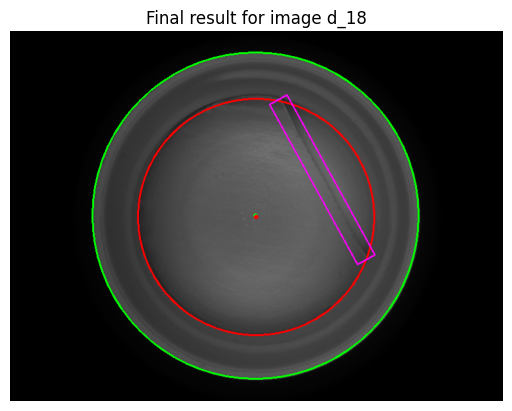

In [279]:
print(final_results)
plt.figure()
plt.title("Final result for image "+img_name)
plt.imshow(img_color_final)
plt.axis('off')
plt.show()

In [280]:
##################### DA TOGLIERE PRIMA DI CONSEGNARE SERVE SOLO PER SALVARE LE IMMAGINI
'''
save_img = cv2.cvtColor(img_color_final, cv2.COLOR_RGB2BGR)
cv2.imwrite("results-images/results_"+img_name+".jpg", save_img)
'''

'\nsave_img = cv2.cvtColor(img_color_final, cv2.COLOR_RGB2BGR)\ncv2.imwrite("results-images/results_"+img_name+".jpg", save_img)\n'